#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Load Excel Files

In [2]:
profile = pd.read_excel("/content/file2_Student_Profile.xlsx")
skills = pd.read_excel("/content/Academic_Skills.xlsx")
placement = pd.read_excel("/content/file1_Placement_Record.xlsx")

# Merge Tables (outer join)

In [3]:
df = profile.merge(skills, on="Student_ID", how="outer")
df = df.merge(placement, on="Student_ID", how="outer")

In [4]:
# Check number of rows and columns
df.shape

(31006, 28)

In [5]:
df.dtypes

,0
Student_ID,object
Gender,object
Age,float64
Department,object
Degree,object
College_Region,object
CGPA,float64
Attendance_%,float64
Internship_Completed,object
Certifications_Count,float64


In [6]:
# Verify Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31006 entries, 0 to 31005
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Student_ID                31006 non-null  object        
 1   Gender                    18077 non-null  object        
 2   Age                       18077 non-null  float64       
 3   Department                6185 non-null   object        
 4   Degree                    18077 non-null  object        
 5   College_Region            18077 non-null  object        
 6   CGPA                      18077 non-null  float64       
 7   Attendance_%              18077 non-null  float64       
 8   Internship_Completed      14570 non-null  object        
 9   Certifications_Count      18077 non-null  float64       
 10  Communication_Score       18077 non-null  float64       
 11  Quantitative_Score        15942 non-null  float64       
 12  Logical_Score     

# Convert Data Types


In [7]:
#These are numeric counts but currently float64 (because of missing values), They should be integers.
#Age , Certifications_Count , Projects_Completed , Interview_Rounds_Cleared, Communication_Score,
# Technical_Score, Soft_Skills_Score, Extra_Curricular_Score, Logical_Score, Quantitative_Score.
df['Age'] = df['Age'].astype('Int64')
df['Certifications_Count'] = df['Certifications_Count'].astype('Int64')
df['Projects_Completed'] = df['Projects_Completed'].astype('Int64')
df['Interview_Rounds_Cleared'] = df['Interview_Rounds_Cleared'].astype('Int64')
df['Communication_Score'] = df['Communication_Score'].round().clip(0,10).astype('Int64')
df['Technical_Score'] = df['Technical_Score'].round().clip(0,100).astype('Int64')
df['Logical_Score'] = df['Logical_Score'].round().clip(0,100).astype('Int64')
df['Quantitative_Score'] = df['Quantitative_Score'].round().clip(0,100).astype('Int64')
df['Soft_Skills_Score'] = df['Soft_Skills_Score'].round().clip(0,10).astype('Int64')
df['Extra_Curricular_Score'] = df['Extra_Curricular_Score'].round().clip(0,10).astype('Int64')
# Fix score ranges and remove decimals

In [8]:
# Columns That Should Be Category Type
# These are text columns with repeated values, so converting them to category
# Gender , Department , Degree , College_Region , Internship_Completed, Hackathon_Participation , Placement_Status , Placement_Type ,Offer_Accepted

cat_cols = ['Gender','Department','Degree','College_Region',
    'Internship_Completed','Hackathon_Participation',
    'Placement_Status','Placement_Type','Offer_Accepted']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [9]:
# Date Column corect

In [10]:
# Columns That Should Stay Float
# CGPA , Attendance_%  ,CTC_LPA
# Because they contain decimal values.

In [11]:
# Again Verify After Conversion

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31006 entries, 0 to 31005
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Student_ID                31006 non-null  object        
 1   Gender                    18077 non-null  category      
 2   Age                       18077 non-null  Int64         
 3   Department                6185 non-null   category      
 4   Degree                    18077 non-null  category      
 5   College_Region            18077 non-null  category      
 6   CGPA                      18077 non-null  float64       
 7   Attendance_%              18077 non-null  float64       
 8   Internship_Completed      14570 non-null  category      
 9   Certifications_Count      18077 non-null  Int64         
 10  Communication_Score       18077 non-null  Int64         
 11  Quantitative_Score        15942 non-null  Int64         
 12  Logical_Score     

In [13]:
df["Placement_Type" ]

,Placement_Type
0,On-Campus
1,NaN
2,Off-Campus
3,NaN
4,On-Campus
...,...
31001,On-Campus
31002,On-Campus
31003,NaN
31004,On-Campus


In [14]:
# Check Missing Values
df.isnull().sum().sort_values(ascending=False)

,0
Logical_Score,30782
Department,24821
CTC_LPA,24821
Placement_Status,19813
Offer_Accepted,19813
Internship_Completed,16436
Technical_Score,15064
Hackathon_Participation,15064
Projects_Completed,15064
Soft_Skills_Score,15064


In [15]:
# Drop Logical_Score
# Logical_Score → 30782 missing out of 31006
# That means almost the entire column is empty, so it has no analytical value.

df.drop('Logical_Score', axis=1, inplace=True)

In [16]:
# Handle Placement_Status and Offer_Accepted
# Fill them with "Not Placed" and "No"

df['Placement_Status'] = df['Placement_Status'].fillna('Not Placed')
df['Offer_Accepted'] = df['Offer_Accepted'].fillna('No')

In [17]:
# Handle Internship_Completed
# This is a Yes/No column, so fill with mode.

df['Internship_Completed'] = df['Internship_Completed'].fillna(df['Internship_Completed'].mode()[0])

In [18]:
# fill Interview_Rounds_Cleared with 0

df['Interview_Rounds_Cleared'] = df['Interview_Rounds_Cleared'].fillna(0)

In [19]:
# Fill Numerical Columns with Mean
cols = [
    'Technical_Score',
    'Soft_Skills_Score',
    'Quantitative_Score',
    'Communication_Score',
    'Extra_Curricular_Score'
]

for col in cols:
    df[col] = df[col].fillna(round(df[col].mean()))

In [20]:
df['Projects_Completed'] = df['Projects_Completed'].fillna(df['Projects_Completed'].median())
# it has Int64 (integer) datatype, and the mean produces a decimal value which cannot be stored in an integer column.

In [21]:
# Fill Department
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])

In [22]:
df['Hackathon_Participation'] = df['Hackathon_Participation'].fillna('No')

In [23]:
df['Company_Name'] = df['Company_Name'].fillna('No Company')

In [24]:
df['Industry_Sector'] = df['Industry_Sector'].fillna('No Industry')

In [25]:
df['Job_Role'] = df['Job_Role'].fillna('No Role')

In [26]:
#Filling Basic Student Information
# Fill float columns with mean
float_cols = ['CGPA','Attendance_%']
for col in float_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill integer columns with median
# Median usually returns a whole number suitable for integers.

int_cols = ['Age','Certifications_Count']
for col in int_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode

cat_cols = ['Gender','College_Region','Degree']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [27]:
# Fill missing salary with 0 (students not placed have no salary)
df['CTC_LPA'] = df['CTC_LPA'].fillna(0)

In [28]:
# Fill placement ID with placeholder

df['Placement_ID'] = df['Placement_ID'].fillna('No_ID')

In [29]:
# Convert categorical to object then fill
# Placement_Type was converted from categorical to object so a new value "No Placement" could be added to fill missing data.

df['Placement_Type'] = df['Placement_Type'].astype('object')
df['Placement_Type'] = df['Placement_Type'].fillna('No Placement')

In [30]:
# Check Missing Values Again
df.isnull().sum().sort_values(ascending=False)

,0
Placement_Date,12929
Gender,0
Student_ID,0
Department,0
Degree,0
College_Region,0
CGPA,0
Attendance_%,0
Internship_Completed,0
Certifications_Count,0


In [31]:
# Placement_Date was left as NaN because non-placed students do not have a placement date.


In [32]:
# Fix Placement vs CTC
df.loc[df['CTC_LPA'] <= 0, 'Placement_Status'] = 'Not Placed'
df.loc[df['CTC_LPA'] > 0, 'Placement_Status'] = 'Placed'

df['CTC_LPA'] = df['CTC_LPA'].apply(lambda x: x*10 if x < 1 else x)
# I MULTIPLY *10 FOR THOSE VALUE LESS THEN 1 AND GREATER THEN 0 FOR BETTER CTC LPA (because mostly ctc_lpa is between range of 0 to 1)

# Fix Offer Accepted
df.loc[df['Placement_Status'] == 'Not Placed', 'Offer_Accepted'] = 'No'

# Fix Degree → Department
degree_to_dept = {
    'B.Tech': 'Engineering',
    'BBA': 'Business',
    'MBA': 'Business',
    'BCA': 'Computer Science',
    'MCA': 'Computer Science'
}

df['Department'] = df['Degree'].map(degree_to_dept)



In [33]:
df.describe()

,Age,CGPA,Attendance_%,Certifications_Count,Communication_Score,Quantitative_Score,Technical_Score,Soft_Skills_Score,Projects_Completed,Extra_Curricular_Score,CTC_LPA,Interview_Rounds_Cleared,Placement_Date
count,31006.0,31006.000000,31006.000000,31006.0,31006.0,31006.0,31006.0,31006.0,31006.0,31006.0,31006.000000,31006.0,18077
mean,22.898729,6.946108,87.425679,1.284493,4.249565,86.014417,61.749016,4.211862,2.442979,5.912791,0.983788,1.599432,2022-05-31 12:15:48.741494528
min,18.0,2.000000,75.000000,0.0,1.0,41.0,20.0,1.0,0.0,1.0,0.000000,0.0,2019-08-01 00:00:00
25%,22.0,6.800000,86.000000,1.0,4.0,86.0,62.0,4.0,2.0,6.0,0.000000,0.0,2021-01-06 00:00:00
50%,23.0,6.946108,87.425679,1.0,4.0,86.0,62.0,4.0,2.0,6.0,0.000000,2.0,2022-05-29 00:00:00
75%,23.0,7.500000,89.000000,2.0,4.0,87.0,74.0,4.0,3.0,6.0,0.000000,3.0,2023-11-01 00:00:00
max,29.0,77.890000,100.000000,5.0,10.0,100.0,91.0,10.0,9.0,10.0,9.890000,5.0,2025-03-30 00:00:00
std,1.88866,5.409594,5.695899,1.105665,1.459476,8.570959,16.334407,1.368398,1.599757,1.66195,2.094552,1.547641,NaN


In [34]:
# TREAT CGPA beacuse of having max value is impossible so remove the rows
df = df[df['CGPA'] <= 10]
# Verify
df['CGPA'].describe()

,CGPA
count,30747.000000
mean,6.479749
std,1.788091
min,2.000000
25%,6.800000
50%,6.946108
75%,7.500000
max,9.100000


In [35]:
# now checking whether dataset contains infinite values in numeric columns.
np.isinf(df.select_dtypes(include=[np.number])).sum()

,0
Age,0
CGPA,0
Attendance_%,0
Certifications_Count,0
Communication_Score,0
Quantitative_Score,0
Technical_Score,0
Soft_Skills_Score,0
Projects_Completed,0
Extra_Curricular_Score,0


# The 0 means there are no infinite values in these columns.

In [36]:
df['Company_Name'].unique()

array(['Deloitte', 'No Company', 'KPMG', 'Amazon', 'Infosys', 'Wipro',
       'HCL', 'Accenture', 'TCS', 'Flipkart', 'EY'], dtype=object)

In [37]:
# Detect special characters

for col in df.select_dtypes(include=['object','category']):
    print("\nColumn:", col)
    print(df[col].unique())


Column: Student_ID
['S10000' 'S10005' 'S10006' ... 'S99991' 'S99993' 'S99999']

Column: Gender
['Male', 'Female', 'Other']
Categories (3, object): ['Female', 'Male', 'Other']

Column: Department
['Engineering' 'Business' 'Computer Science']

Column: Degree
['B.Tech', 'MBA', 'BCA', 'MCA', 'BBA']
Categories (5, object): ['B.Tech', 'BBA', 'BCA', 'MBA', 'MCA']

Column: College_Region
['North', 'South', 'East', 'West']
Categories (4, object): ['East', 'North', 'South', 'West']

Column: Internship_Completed
['Yes', 'No']
Categories (2, object): ['No', 'Yes']

Column: Hackathon_Participation
['No', 'Yes']
Categories (2, object): ['No', 'Yes']

Column: Placement_ID
['P07588' 'No_ID' 'P12935' ... 'P09298' 'P09712' 'P15187']

Column: Company_Name
['Deloitte' 'No Company' 'KPMG' 'Amazon' 'Infosys' 'Wipro' 'HCL'
 'Accenture' 'TCS' 'Flipkart' 'EY']

Column: Industry_Sector
['Consulting' 'No Industry' 'E-Commerce' 'IT']

Column: Job_Role
['Data Analyst' 'No Role' 'Software Engineer' 'Developer' 'HR

# The dataset did not contain inconsistent or special character values, indicating that categorical data is clean and standardized.

In [38]:
# checking if any row appears more than once in the dataset.

df.duplicated().sum()

np.int64(0)

# The result shows that there are no duplicate records present in the dataset.

In [39]:
# Separate categorical , numerical columns and Date columns

num_cols = df.select_dtypes(include=['int64','float64','Int64']).columns
cat_cols = df.select_dtypes(include=['object','category']).columns
date_cols = df.select_dtypes(include=['datetime']).columns

In [40]:
cat_cols


Index(['Student_ID', 'Gender', 'Department', 'Degree', 'College_Region',
       'Internship_Completed', 'Hackathon_Participation', 'Placement_ID',
       'Company_Name', 'Industry_Sector', 'Job_Role', 'Placement_Status',
       'Placement_Type', 'Offer_Accepted'],
      dtype='object')

In [41]:
num_cols

Index(['Age', 'CGPA', 'Attendance_%', 'Certifications_Count',
       'Communication_Score', 'Quantitative_Score', 'Technical_Score',
       'Soft_Skills_Score', 'Projects_Completed', 'Extra_Curricular_Score',
       'CTC_LPA', 'Interview_Rounds_Cleared'],
      dtype='object')

In [42]:
date_cols

Index(['Placement_Date'], dtype='object')

# Univariate Analysis (Single Variable)
# Purpose: Understand distribution of each important variable

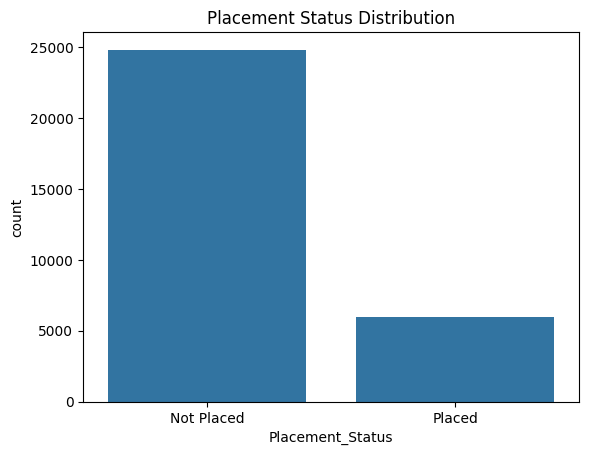

In [43]:
#Placement Status Distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Placement_Status', data=df)
plt.title("Placement Status Distribution")
plt.show()

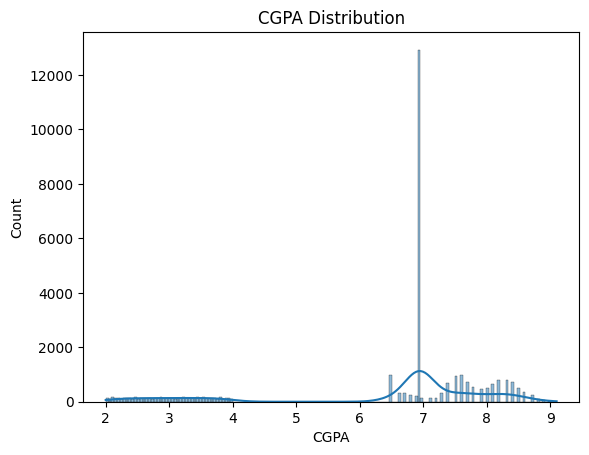

In [44]:
# CGPA Distribution

sns.histplot(df['CGPA'], kde=True)
plt.title("CGPA Distribution")
plt.show()

In [45]:
# The CGPA distribution shows that most students have CGPA values concentrated around 6.5–8, indicating generally moderate to good academic performance

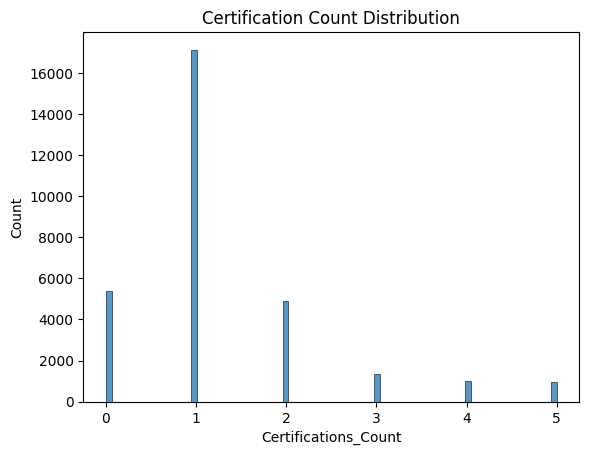

In [46]:
# Certification Count
sns.histplot(df['Certifications_Count'])
plt.title("Certification Count Distribution")
plt.show()

In [47]:
# Most students possess one certification, while fewer students have multiple certifications.

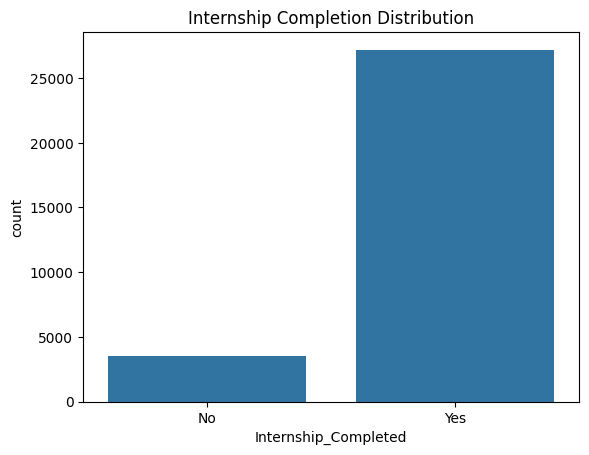

In [48]:
# Internship Completed

sns.countplot(x='Internship_Completed', data=df)
plt.title("Internship Completion Distribution")
plt.show()

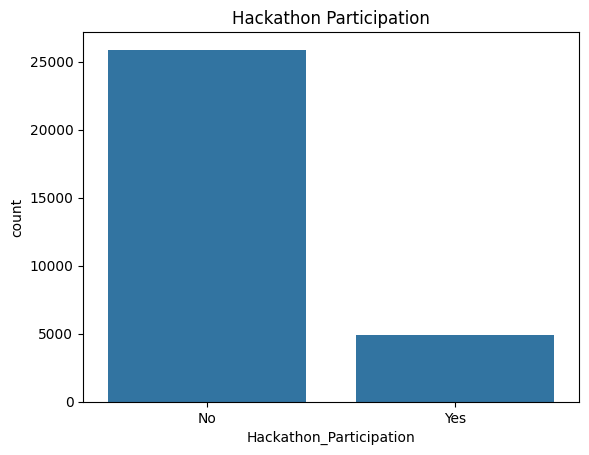

In [49]:
# Hackathon Participation

sns.countplot(x='Hackathon_Participation', data=df)
plt.title("Hackathon Participation")
plt.show()

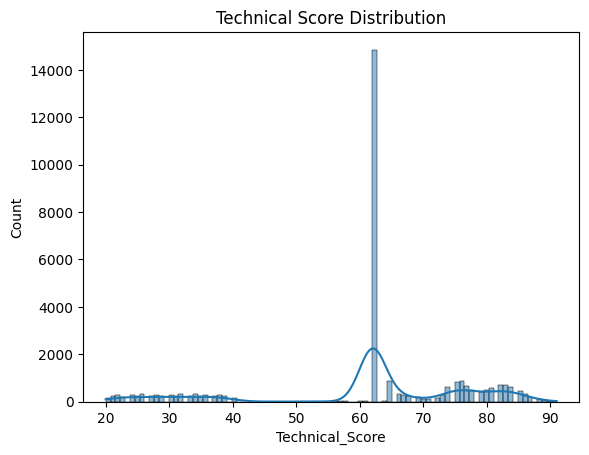

In [50]:
# Technical Score
sns.histplot(df['Technical_Score'], kde=True)
plt.title("Technical Score Distribution")
plt.show()

In [51]:
# The distribution shows that most students score around 60–65 in technical skills, with fewer students achieving higher scores above 75.

# Bivariate Analysis (Relationship Between Two Variables)
# Factors affecting Placement Status

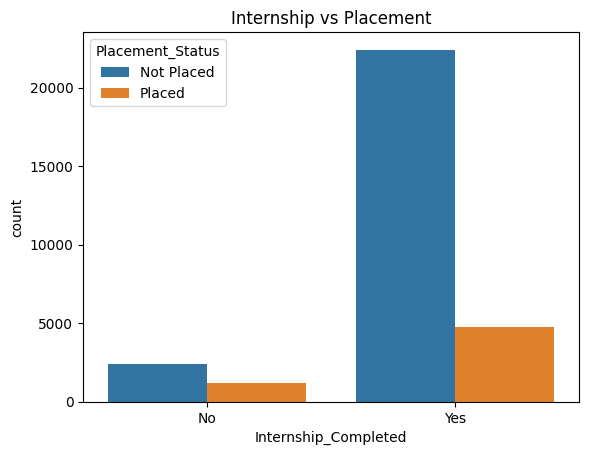

In [52]:
# Internship vs Placement
sns.countplot(x='Internship_Completed', hue='Placement_Status', data=df)
plt.title("Internship vs Placement")
plt.show()

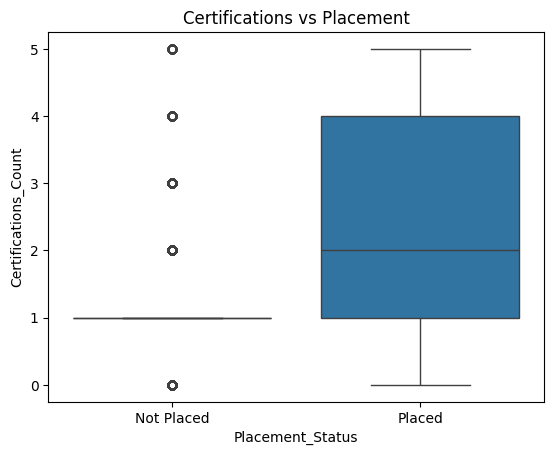

In [53]:
# Certification vs Placement
sns.boxplot(x='Placement_Status', y='Certifications_Count', data=df)
plt.title("Certifications vs Placement")
plt.show()

In [54]:
# Placed students have more certifications than non-placed students.

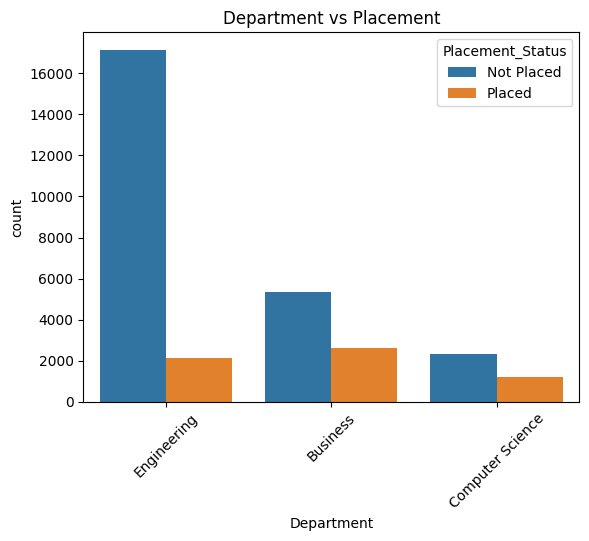

In [55]:
# Department vs Placement
sns.countplot(x='Department', hue='Placement_Status', data=df)
plt.title("Department vs Placement")
plt.xticks(rotation=45)
plt.show()

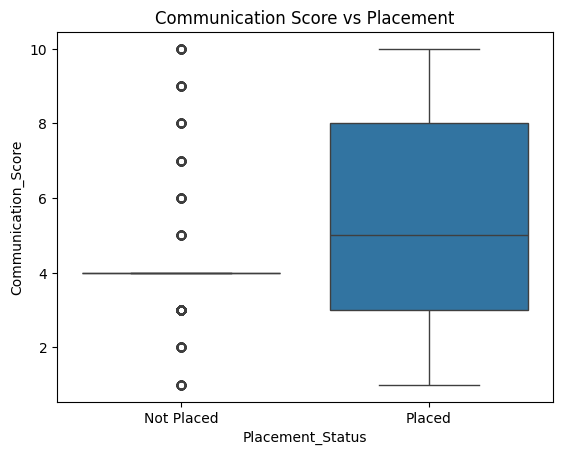

In [56]:
# Communication Score vs Placement
sns.boxplot(x='Placement_Status', y='Communication_Score', data=df)
plt.title("Communication Score vs Placement")
plt.show()

In [57]:
# The boxplot shows that placed students generally have higher communication scores compared to not placed students.

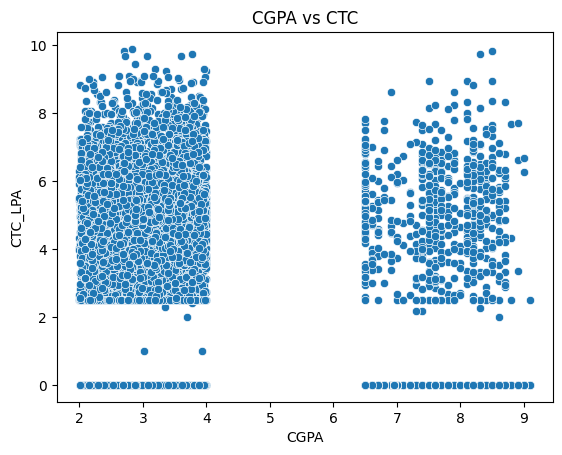

In [58]:
# CGPA vs CTC
sns.scatterplot(x='CGPA', y='CTC_LPA', data=df)
plt.title("CGPA vs CTC")
plt.show()

In [59]:
# Higher CGPA shows a slight positive relationship with CTC, but most students still receive similar salary packages.

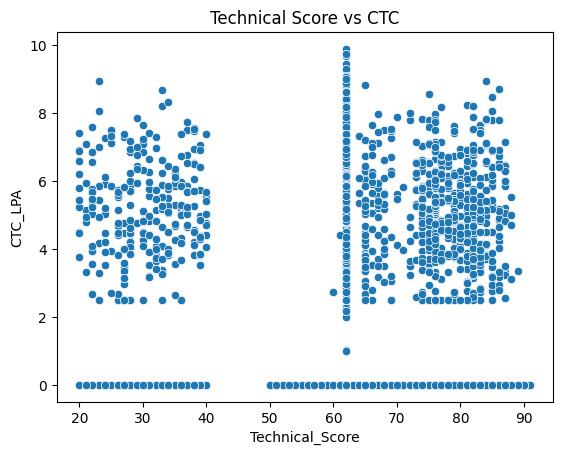

In [60]:
# Technical Score vs CTC
sns.scatterplot(x='Technical_Score', y='CTC_LPA', data=df)
plt.title("Technical Score vs CTC")
plt.show()

In [61]:
# Technical scores have a weak relationship with CTC, with most students receiving similar salary packages.

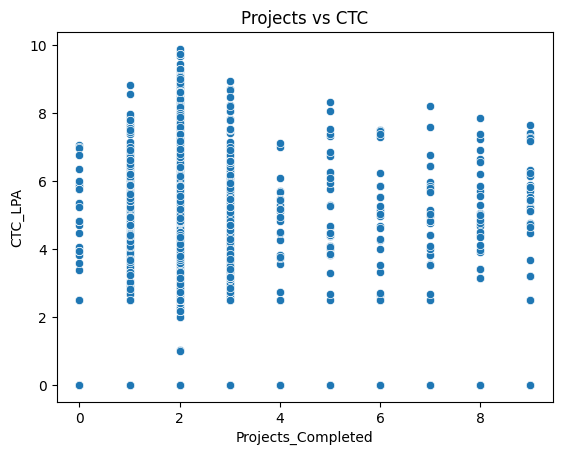

In [62]:
# Projects vs CTC
sns.scatterplot(x='Projects_Completed', y='CTC_LPA', data=df)
plt.title("Projects vs CTC")
plt.show()

In [63]:
# Students with different numbers of projects mostly receive similar CTC packages, indicating a weak relationship.

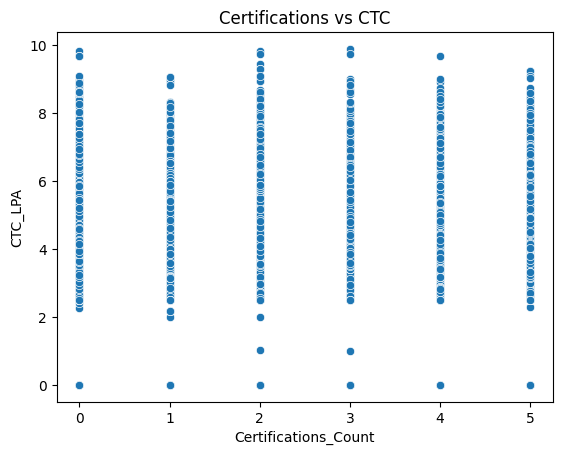

In [64]:
# Certifications vs CTC
sns.scatterplot(x='Certifications_Count', y='CTC_LPA', data=df)
plt.title("Certifications vs CTC")
plt.show()

In [65]:
# CTC values are mostly similar across different certification counts, indicating a weak relationship.

In [66]:
df.to_excel("NEWEST_CLEANED_PLACEMENT_FILE.xlsx", index=False)

In [67]:
import pandas as pd

df = pd.read_excel("/content/project_file.xlsx")

df.head()

,Student_ID,Gender,Age,Department,Degree,College_Region,CGPA,Attendance_%,Internship_Completed,Certifications_Count,...,Placement_ID,Company_Name,Industry_Sector,Job_Role,CTC_LPA,Placement_Status,Placement_Type,Interview_Rounds_Cleared,Offer_Accepted,Placement_Date
0,S10000,Male,25,Engineering,B.Tech,North,6.600000,78.000000,Yes,0,...,P07588,Deloitte,Consulting,Data Analyst,0.00,Not Placed,On-Campus,3,No,2023-01-10
1,S10005,Male,23,Engineering,B.Tech,South,6.946108,87.425679,Yes,1,...,No_ID,No Company,No Industry,No Role,0.00,Not Placed,No Placement,0,No,NaT
2,S10006,Male,21,Business,MBA,South,2.960000,93.000000,Yes,2,...,P12935,KPMG,Consulting,Software Engineer,7.37,Placed,Off-Campus,4,Yes,2020-06-13
3,S10011,Male,23,Engineering,B.Tech,South,6.946108,87.425679,Yes,1,...,No_ID,No Company,No Industry,No Role,0.00,Not Placed,No Placement,0,No,NaT
4,S10014,Female,21,Computer Science,BCA,South,6.500000,92.000000,Yes,1,...,P03240,Amazon,E-Commerce,Data Analyst,0.00,Not Placed,On-Campus,2,No,2024-06-20


#OUTLIER

In [68]:
# Outlier detection was applied only to continuous features like CGPA, attendance, and etc, as extreme values in these can affect model performance.
# Count-based features and the target variable were not treated because their higher values represent valid and meaningful information.

In [69]:
# Outlier detection Col
cols_for_outliers = [
    'CGPA',
    'Attendance_%',
    'Communication_Score',
    'Quantitative_Score',
    'Technical_Score',
    'Soft_Skills_Score',
    'Extra_Curricular_Score'
]

In [70]:
# skip
[
    'Age',                     # mostly natural variation
    'Certifications_Count',    # count
    'Projects_Completed',      # count
    'Interview_Rounds_Cleared',# count
    'CTC_LPA'                  # target
]

['Age',
 'Certifications_Count',
 'Projects_Completed',
 'Interview_Rounds_Cleared',
 'CTC_LPA']

In [71]:
# FOR Outlier:
            # Scores & % → should be in range
            # Outliers = abnormal → affect ML
# Skip:
           # Counts → high value = good performance
           # CTC → salary (important outcome)
           # Age → not critical here

#Outlier Detection

In [72]:

for col in cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} → {len(outliers)} outliers")

CGPA → 6704 outliers
Attendance_% → 9566 outliers
Communication_Score → 7683 outliers
Quantitative_Score → 14490 outliers
Technical_Score → 5210 outliers
Soft_Skills_Score → 7001 outliers
Extra_Curricular_Score → 13291 outliers


In [73]:
# All outliers were not treated because many of them are genuine values, and modifying them would lead to loss of important information.

# Treat Outliers (Final Selected Columns)

In [74]:
cols_for_outlier = [
    'CGPA',
    'Technical_Score',
    'Communication_Score'
]

for col in cols_for_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

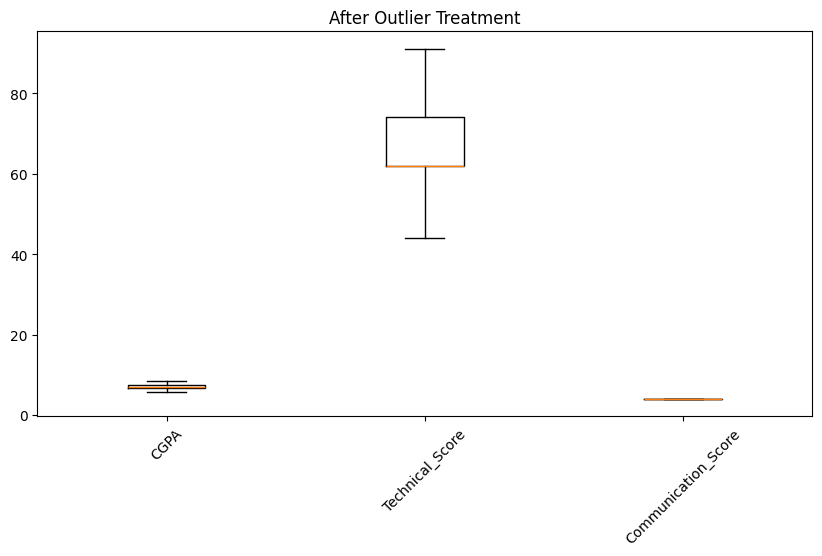

In [75]:
# CHECK AGAIN
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.boxplot([df[col] for col in cols_for_outlier], tick_labels=cols_for_outlier)
plt.xticks(rotation=45)
plt.title("After Outlier Treatment")
plt.show()

In [76]:
# Irrelevant features such as unique identifiers were removed as they do not contribute to prediction and may negatively impact model performance.
# pure IDs, no value for ML

df = df.drop(['Student_ID','Placement_ID'], axis=1)

In [77]:
df['Placement_Year'] = df['Placement_Date'].dt.year
df = df.drop('Placement_Date', axis=1)

# STATISTICS


# Z-TEST

In [78]:
from statsmodels.stats.weightstats import ztest


placed = df[df['Placement_Status'] == 'Placed']['Technical_Score'].dropna()
not_placed = df[df['Placement_Status'] == 'Not Placed']['Technical_Score'].dropna()

print("Sample size of placed:", len(placed))
print("Sample size of not placed:", len(not_placed))

# RULE:
# If sample size > 30, Z-test can be used (academic rule)

# Sample Mean
mean_placed = placed.mean()
mean_not_placed = not_placed.mean()

# Sample Standard Deviation
sd_placed = placed.std()
sd_not_placed = not_placed.std()

print("Placed -> Mean:", mean_placed, "SD:", sd_placed)
print("Not Placed -> Mean:", mean_not_placed, "SD:", sd_not_placed)

# Z-test
z_stat, p_value = ztest(placed, not_placed)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

# Decision + Insight
if p_value < 0.05:
    print("Reject H0 → Significant difference in Technical Score")
    print("Insight: There is a significant difference in technical scores, but higher technical score does not guarantee placement. Other factors also influence placement.")
else:
    print("Fail to Reject H0 → No significant difference")
    print("Insight: Technical score does not significantly influence placement")

Sample size of placed: 5938
Sample size of not placed: 24809
Placed -> Mean: 62.81559447625463 SD: 6.862482261141581
Not Placed -> Mean: 64.39582409609416 SD: 12.79942728788188
Z-statistic: -9.202316879230766
P-value: 3.503135102133302e-20
Reject H0 → Significant difference in Technical Score
Insight: There is a significant difference in technical scores, but higher technical score does not guarantee placement. Other factors also influence placement.


In [79]:
# I used a two-tailed Z-test to compare Technical Scores between placed and not placed students.
# The results show a statistically significant difference in Technical Scores; however, higher technical scores do not necessarily lead to better placement outcomes,
# indicating that technical skills alone are not the key driver of employability.

In [80]:
#Z-statistic = -9.20 (approx)
#It measures the difference between the two groups (Placed vs Not Placed).
#The large absolute value (~9.2) indicates a strong difference between the groups.
#The negative sign indicates direction (Placed mean < Not Placed mean).

#P-value = 3.5e-20
#This is not exactly zero, but extremely small (much less than 0.05).
#So, the result is highly statistically significant.

# Chi-Square Test

In [81]:
from scipy.stats import chi2_contingency
import pandas as pd

# Contingency Table
table = pd.crosstab(df['Internship_Completed'], df['Placement_Status'])
print("Contingency Table:\n", table)

# Sample size
print("\nTotal Sample Size:", table.values.sum())

# Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(table)
print("\nChi-square:", chi2)
print("P-value:", p_value)

# Hypothesis
print("\nH0: Internship Completion and Placement_Status are independent")
print("H1: Internship Completion and Placement_Status are related")

# Decision + Business Insight (FIXED)
if p_value < 0.05:
    print("\nDecision: Reject Null Hypothesis (H0)")
    print("Conclusion: Internship completion is significantly associated with placement")
    print("Insight: There is a relationship between internship and placement")
else:
    print("\nDecision: Fail to Reject Null Hypothesis (H0)")
    print("Conclusion: Internship completion does not significantly affect placement")
    print("Insight: Internships alone do not strongly influence placement outcomes")

Contingency Table:
 Placement_Status      Not Placed  Placed
Internship_Completed                    
No                          2391    1162
Yes                        22418    4776

Total Sample Size: 30747

Chi-square: 461.4007179502511
P-value: 2.382713615412439e-102

H0: Internship Completion and Placement_Status are independent
H1: Internship Completion and Placement_Status are related

Decision: Reject Null Hypothesis (H0)
Conclusion: Internship completion is significantly associated with placement
Insight: There is a relationship between internship and placement


In [82]:
# Chi-square value = 461.40
                         # Measures difference between expected vs actual data
                         # Large value (461) = strong relationship
                         # Bigger value = stronger relationship

# 2. P-value = 2.38e-102
                        # Extremely small number (≈ 0.000000…)
                       # Clearly < 0.05
                       #  Very strong statistical significance

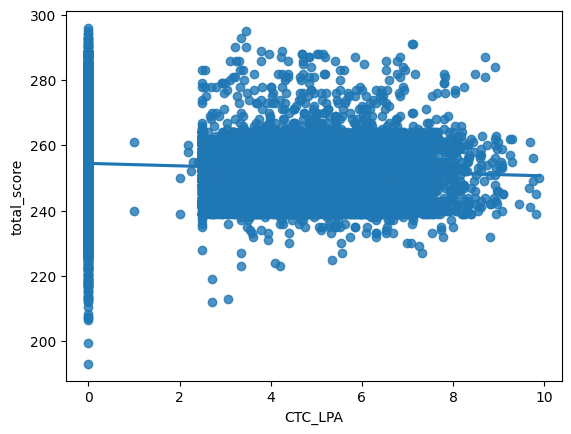

In [83]:
# create total_score column

df["total_score"]=df['Attendance_%']+df["Communication_Score"]+df["Quantitative_Score"]+df["Technical_Score"]+df["Soft_Skills_Score"]+df["Projects_Completed"]+df["Extra_Curricular_Score"]
sns.regplot(x=df["CTC_LPA"],y=df["total_score"])
plt.show()


# Encoding

In [84]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Heatmap (AFTER ENCODING)

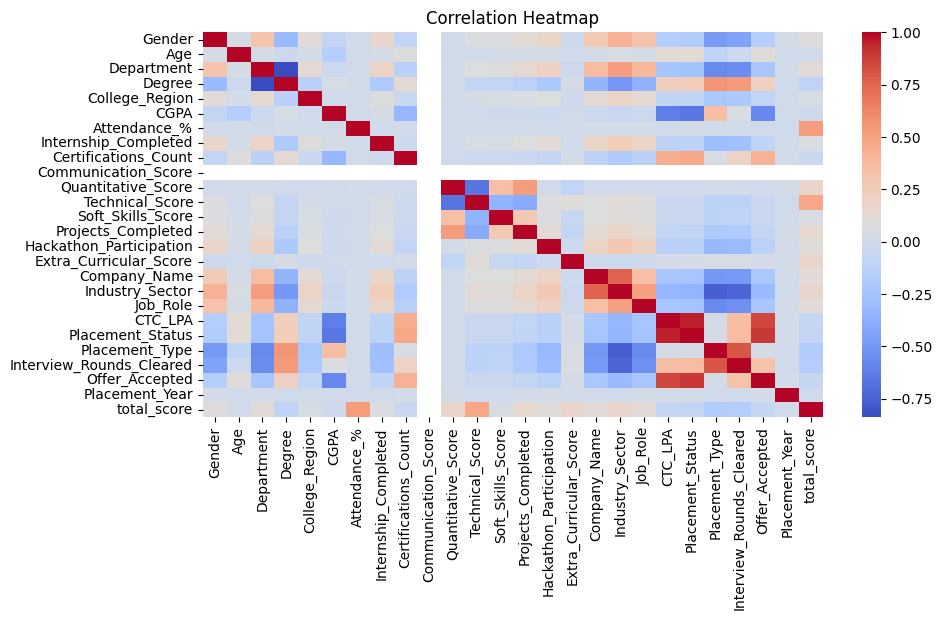

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [86]:
# After encoding, a heatmap was used to analyze feature relationships and support feature selection.

# Move To The ML

# Logistic Regression

In [87]:
# Drop unwanted columns
# “Feature selection ensures that only meaningful and independent variables are used,
# improving model accuracy and preventing misleading predictions caused by data leakage and irrelevant features
# I removed columns causing data leakage, low correlation, and high cardinality to improve model reliability and avoid overfitting.
#These columns directly reveal placement outcome, so they were removed to prevent data leakage.

# created df_clean for classification (Placement)
df_clean = df.drop([
    'Placement_Type',
    'Offer_Accepted',
    'Interview_Rounds_Cleared',
    'Company_Name',
    'Age',
    'Attendance_%',
    'Placement_Year',
    'CTC_LPA',
    'Industry_Sector',
    'Job_Role'
], axis=1)



In [88]:
# Label Encoding for categorical columns

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = ['Gender', 'Department', 'Degree', 'College_Region']
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
print("Encoding Done")

Encoding Done


In [89]:
# Features & Target

X = df_clean.drop('Placement_Status', axis=1)
y = df_clean['Placement_Status']

In [90]:
# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (24597, 15)
Test shape: (6150, 15)


In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Fit on train, transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Scaling Done")

Scaling Done


In [92]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Model
log_model = LogisticRegression()
# Train
log_model.fit(X_train, y_train)
# Predict
y_pred = log_model.predict(X_test)

# Accuracya
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9596747967479675
Confusion Matrix:
 [[4851  134]
 [ 114 1051]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98      4985
           1       0.89      0.90      0.89      1165

    accuracy                           0.96      6150
   macro avg       0.93      0.94      0.93      6150
weighted avg       0.96      0.96      0.96      6150



In [93]:
# The model performs well with 96% accuracy and is able to correctly identify 90% of placed students,
# making it reliable for predicting placement outcomes.

In [94]:
# The model achieves 96% accuracy with strong recall for placed students.
# However, a small number of false negatives exist, meaning some capable students are predicted as not placed.

# KNN

In [95]:
# Drop unwanted columns for knn model
# Drop irrelevant and post-placement columns to avoid data leakage
# and keep only meaningful features for KNN classification
df_knn = df.drop([
    'Offer_Accepted',
    'Interview_Rounds_Cleared',
    'Company_Name',
    'Age',
    'Attendance_%',
    'Placement_Year',
    'CTC_LPA',
    'Placement_Status',
    'Industry_Sector',
    'Job_Role'
], axis=1)

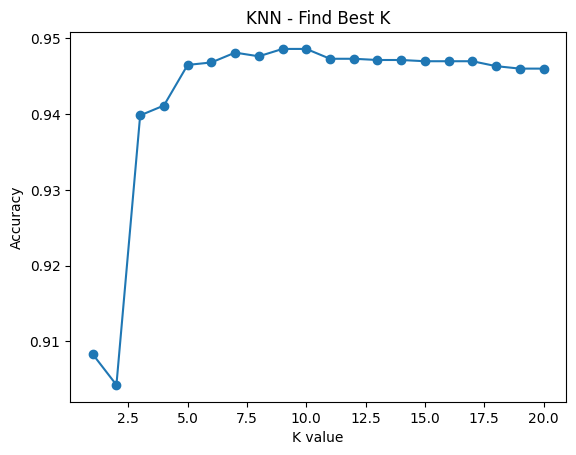

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


X = df_knn.drop('Placement_Type', axis=1)
y = df_knn['Placement_Type']


# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Find Best K
accuracy = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy.append(accuracy_score(y_test, y_pred))
# Plot graph
plt.plot(range(1, 21), accuracy, marker='o')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('KNN - Find Best K')
plt.show()

In [97]:
df['Placement_Type'].value_counts()

,count
Placement_Type,
0,12929
2,11907
1,5911


In [98]:
# Train Final Model (Best K)
best_k = 11
print("Final Chosen K:", best_k)

# fit
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

# Prediction
y_pred_knn = knn.predict(X_test)

# Evaluation
acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", acc_knn)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

Final Chosen K: 11
KNN Accuracy: 0.9473170731707317
Confusion Matrix:
 [[2585    0    2]
 [  32 1025  103]
 [  50  137 2216]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      2587
           1       0.88      0.88      0.88      1160
           2       0.95      0.92      0.94      2403

    accuracy                           0.95      6150
   macro avg       0.94      0.94      0.94      6150
weighted avg       0.95      0.95      0.95      6150



In [99]:
# The KNN model shows that students with similar academic and skill profiles tend to have similar placement outcomes.
# suggesting that placement depends on additional hidden factors beyond similarity

# Linear Regression

In [100]:
# MULTIPLE LINEAR REGRESSION

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Dropping columns that are irrelevant, high in cardinality, or contain post-placement information
# This helps prevent data leakage and ensures the model learns only meaningful patterns
df_reg = df.drop([
    'Placement_Year',
    'Company_Name',
    'Industry_Sector',
    'Job_Role',
    'Placement_Type',
    'Interview_Rounds_Cleared',
    'Offer_Accepted',
    'Placement_Status'
], axis=1)

In [101]:
# Features & Target
X = df_reg.drop(['CTC_LPA'], axis=1)
y = df_reg['CTC_LPA']

In [102]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [103]:
# Model
lr = LinearRegression()
# Train
lr.fit(X_train, y_train)



#  Predict
y_pred = lr.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.5379232457244792
MAE: 0.9192543506781348
MSE: 2.0057497462833176
RMSE: 1.416244945722073


In [104]:
# R² ≈ 0.54 → Moderate relationship between features and target variable
# MAE ≈ 0.92 → Average prediction error is around 0.92 units
# MSE ≈ 2.00 → Some prediction errors are present, including larger deviations
# RMSE ≈ 1.41 → On average, predictions deviate by about 1.4 units from actual values

# K MEAN

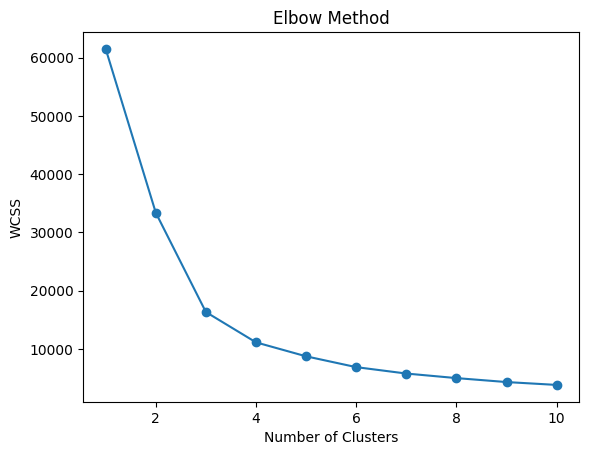

In [105]:
# ELBOW METHOD

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


X = df[['total_score', 'CTC_LPA']]

le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
# Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# create siluette clusters to finalise k


For n_clusters = 2 The average silhouette_score is : 0.5265025078818308


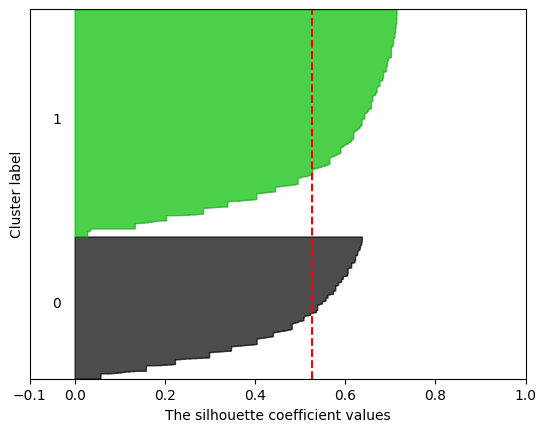

For n_clusters = 3 The average silhouette_score is : 0.517902703887748


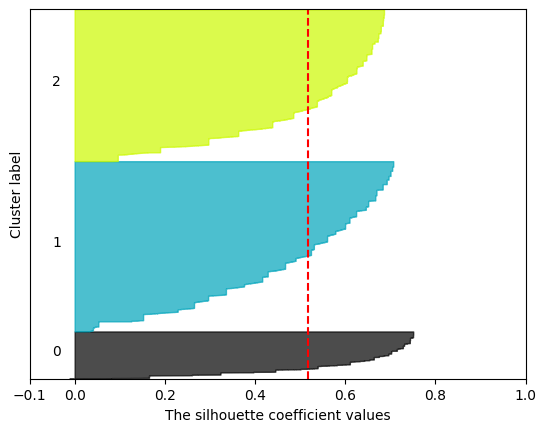

For n_clusters = 4 The average silhouette_score is : 0.4776058242787711


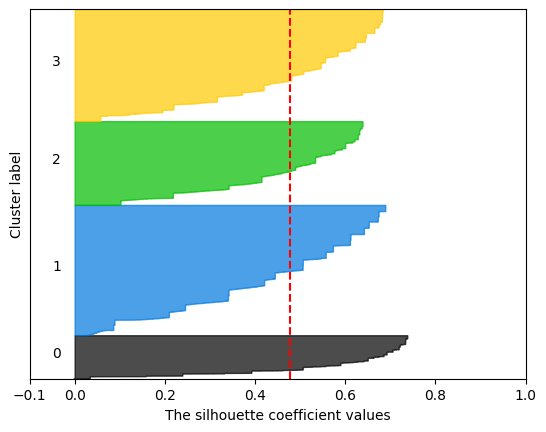

For n_clusters = 5 The average silhouette_score is : 0.43798735294944957


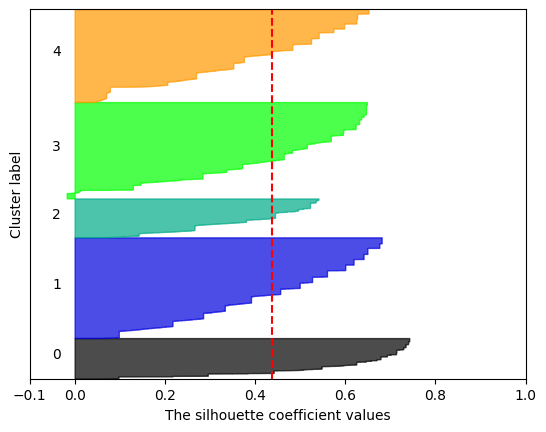

For n_clusters = 6 The average silhouette_score is : 0.4192544868508311


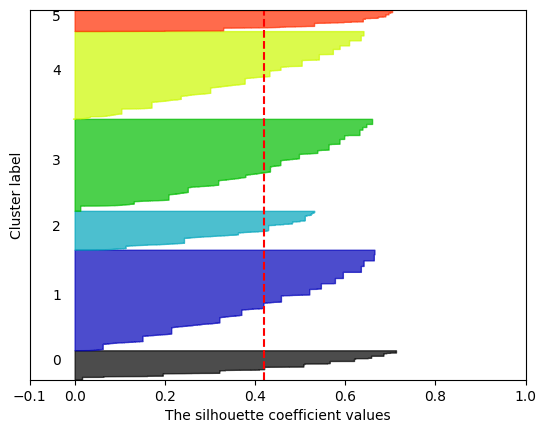

For n_clusters = 7 The average silhouette_score is : 0.4028947722231036


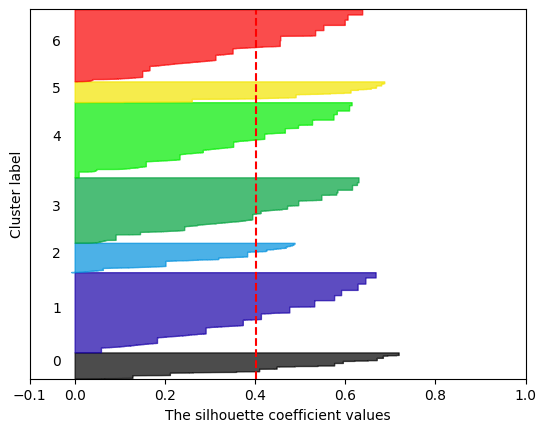

In [106]:
#silhouette_score

import numpy as np
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm
range_n_clusters = [2, 3, 4, 5, 6, 7]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, ax1 = plt.subplots(1, 1)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
             np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10  # 10 for spacing between clusters

    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # Vertical line for average silhouette score
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear y-axis labels
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.show()

# FINAL K-MEANS CLUSTERING  (k = 3)

In [107]:

# Apply K-Means with selected K = 3
#  Elbow method suggested optimal clusters = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [108]:
# Cluster distribution
#  See how data is divided
print("Cluster Distribution:\n", df['Cluster'].value_counts())

Cluster Distribution:
 Cluster
0    16127
2     9153
1     5467
Name: count, dtype: int64


In [109]:
# Full cluster analysis
# Understand how features differ across clusters
df.groupby('Cluster').mean(numeric_only=True)

,Gender,Age,Department,Degree,College_Region,CGPA,Attendance_%,Internship_Completed,Certifications_Count,Communication_Score,...,Company_Name,Industry_Sector,Job_Role,CTC_LPA,Placement_Status,Placement_Type,Interview_Rounds_Cleared,Offer_Accepted,Placement_Year,total_score
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.735847,22.785267,1.414460,0.932411,1.787437,7.268006,85.592547,0.893967,1.069573,4.0,...,6.262355,1.933156,3.740063,0.040486,0.015874,1.053637,1.466423,0.013084,2021.901729,247.823340
1,0.559722,23.379367,0.916408,1.722883,1.603256,5.940973,87.413938,0.801902,2.353210,4.0,...,4.641485,0.982989,2.663801,5.248575,1.000000,1.002195,2.745381,0.833364,2021.919883,252.089080
2,0.793838,22.821807,1.552496,0.713100,1.836447,7.169770,90.648597,0.916967,1.061182,4.0,...,6.693871,2.189446,4.028297,0.070826,0.023490,0.792527,1.114389,0.018355,2021.906484,266.368252


In [110]:
# EVALUATION METRICS
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
# Silhouette Score
sil_score = silhouette_score(X_scaled, df["Cluster"]) #Measures how well clusters are separated (higher = better)
#  Davies-Bouldin Index
db_index = davies_bouldin_score(X_scaled, df["Cluster"]) # Measures cluster similarity (lower = better)
# Calinski-Harabasz Index
ch_index = calinski_harabasz_score(X_scaled, df["Cluster"]) #Measures cluster separation (higher = better)
# WCSS (Inertia)
wcss = kmeans.inertia_   #Measures compactness of clusters (lower = better)

# Print evaluation
print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_index)
print("Calinski-Harabasz Index:", ch_index)
print("WCSS (Inertia):", wcss)

Silhouette Score: 0.5399039979018109
Davies-Bouldin Index: 0.60950858108973
Calinski-Harabasz Index: 42437.50610294734
WCSS (Inertia): 16351.736153376494


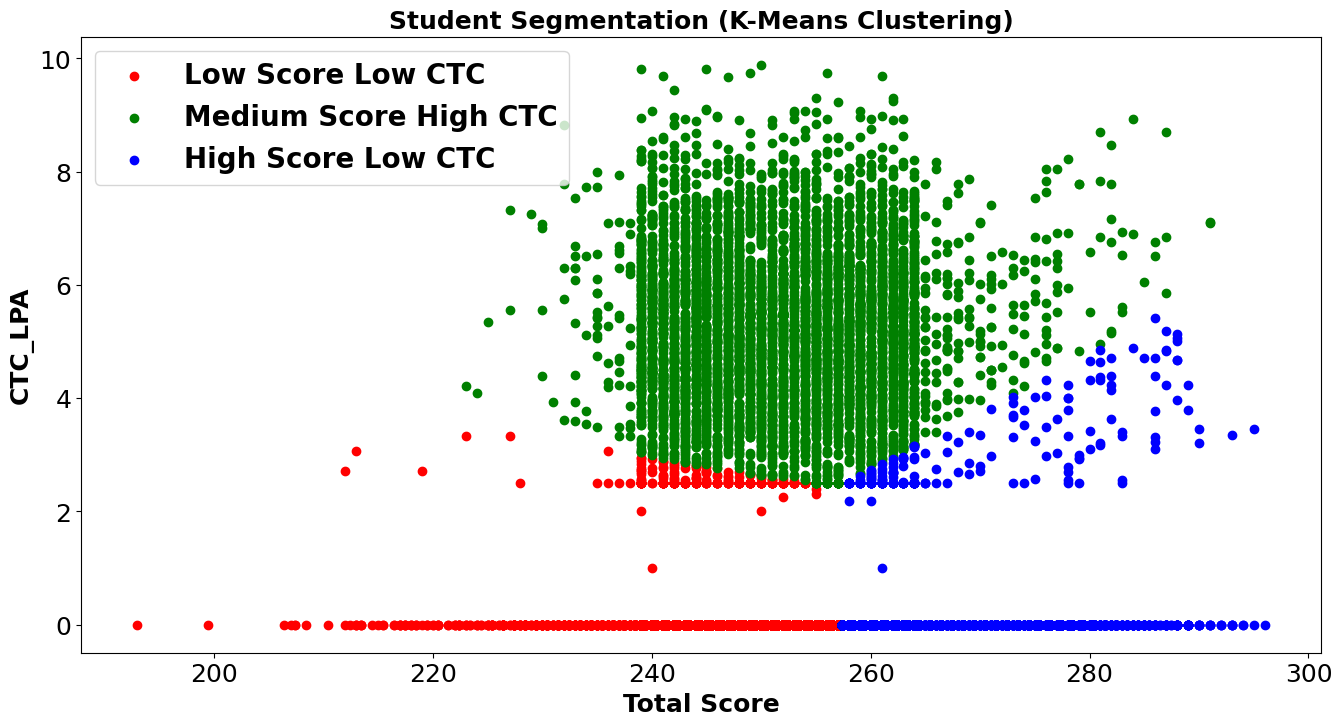

In [111]:
import matplotlib.pyplot as plt

X = df[['total_score', 'CTC_LPA']]

# Segment names
segments = [
    'Low Score Low CTC',
    'Medium Score High CTC',
    'High Score Low CTC'
]

# Colors
colors = ['red', 'green', 'blue']

plt.figure(figsize=(16,8))

# Loop through clusters
for i in range(kmeans.n_clusters):
    plt.scatter(
        df[df['Cluster'] == i]['total_score'],
        df[df['Cluster'] == i]['CTC_LPA'],
        c=colors[i],
        label=segments[i]
    )

# Title and labels (bold + size)
plt.title('Student Segmentation (K-Means Clustering)', fontsize=18, fontweight='bold')
plt.xlabel('Total Score', fontsize=18, fontweight='bold')
plt.ylabel('CTC_LPA', fontsize=18, fontweight='bold')


plt.legend(
    loc='upper left',
    prop={'size': 20, 'weight': 'bold'}
)

# Axis numbers size
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.show()